# Get the final plot and inference
----

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from get_model_probabilities import *
import scienceplots
from scipy.stats import binned_statistic

plt.style.use(["science","grid"])

## First fit the relation between threshold and cross-section

In [16]:
def g1_func( snr, a, b, c, d ):

    return a + b*np.exp( snr /c) + d*snr
    #return a + b*snr + c*snr**2
    #return a+b*snr

def g1_inv( snr, a, b, c, d):
    
    #return np.log((snr - a)/b)*c
    
    
    return ( snr - a)/d - c*lambertw( b/(c*d)*np.exp((snr-a)/(c*d)))
    #return (snr -a)/b
    
def jacob( snr, a, b, c, d):
    
    z = b/(c*d)*np.exp((snr-a)/(c*d))
    
    deriv = c*lambertw(z) / (z*(1+lambertw(z) ))
    return snr/d - deriv

    #return c/(snr-a)
    #return 1./b

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/output_to_model.pdf'.
$0.46_{-0.41}^+{0.34}


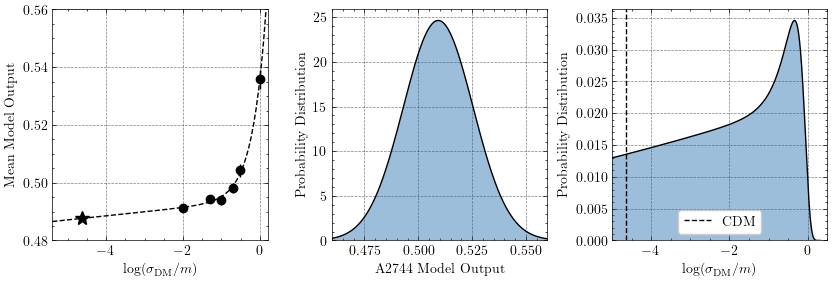

In [27]:
ifilter = 'concat'

models, probs = pkl.load(open("pickles/probs_for_cross_concat_nob1.pkl","rb"))
models, probabilities, probabilities_noise =pkl.load(open("pickles/model_on_data.pkl","rb"))
nmodels = probabilities[ifilter].shape[0]

thresholds = 1.-np.array([ np.mean(np.concat([ j for j in probs[i]])) for i in probs.keys()])

err = np.array([ np.std(np.concat([ j for j in probs[i]]))/np.sqrt(300.) for i in probs.keys()])
cross = np.array([float(i) for i in probs.keys() ])

cdm_thresh = thresholds[ cross == 0]
cdm_err = err[ cross == 0]


err = err[ cross != 0 ]
thresholds = thresholds[ cross != 0 ]
cross = cross[ cross != 0]

#cross[cross==0] = 1e-3
cross = np.log10(cross)


    
## CURVE FITTING
popt, pcov = curve_fit(
                g1_func,
                cross,
                thresholds,
                sigma=err)

popt_err = np.sqrt(np.diag(pcov))

cdm_cross = g1_inv( cdm_thresh, *popt)


fig, axarr = plt.subplots(1,3,figsize=(10,3))

fig.subplots_adjust(wspace=0.3)
#####################

###PLOT 1

#####################
ax = axarr[0]
ax.errorbar(cross,thresholds,err,fmt='ko')
ax.plot( cdm_cross, cdm_thresh, 'k*', ms=10)
xplot=np.linspace(-5.4,1,100)
ax.plot( xplot, g1_func(xplot, *popt),'k--')
ax.set_ylim(0.48,0.56)
ax.set_xlim(-5.4,0.2)
ax.set_xlabel("log($\sigma_{\\rm DM}/m$)")
ax.set_ylabel("Mean Model Output")

#####################

###PLOT 2

#####################
ax = axarr[1]

xpdf = np.linspace(0.4,0.6,1000)
thresh = 1-probabilities['concat']
correction = 2.08
corr = correction*nmodels**0.5/nmodels**0.38

ypdf = np.prod([ norm.pdf(xpdf, i, corr*np.std(probabilities['concat'])) for i in thresh ],axis=0)
ypdf /= np.sum(ypdf)*(xpdf[1]-xpdf[0])

ax.plot(xpdf, ypdf, 'k-')
ax.fill_between(xpdf, ypdf, alpha=0.4)






ylim = ax.get_ylim()[1]
#ax.plot([cdm_thresh,cdm_thresh],[0,ylim*1.1],'k--', label='CDM')
ax.set_xlabel("A2744 Model Output")
ax.set_ylabel("Probability Distribution")
ax.set_ylim(0,ylim)
ax.set_xlim(0.46,0.56)
#####################


###PLOT 3

#####################

ax = axarr[2]



#ax.plot(xpdf, ypdf,'k-')

#xc = (x[1:] + x[:-1])/2.


x_cross = g1_inv( xpdf, *popt)
f_cross = ypdf *jacob(xpdf, *popt)
f_cross = f_cross/np.sum(f_cross)/(x_cross[1]-x_cross[0])

ax.plot(x_cross,f_cross, 'k-')
ax.fill_between(x_cross, f_cross, alpha=0.4)

ax.set_ylim(ax.get_ylim())
ax.set_xlim(-5, 0.5)

ax.plot([cdm_cross,cdm_cross],[0,ax.get_ylim()[1]*1.1],'k--', label='CDM')
ax.set_xlabel("log($\sigma_{\\rm DM}/m)$")
ax.set_ylabel("Probability Distribution")

ax.legend()
max_like_log = x_cross[np.argmax(f_cross)]
cumsum = np.cumsum(f_cross)/np.sum(f_cross)

low, high = [x_cross[ np.argmin(np.abs(cumsum-0.16))], x_cross[ np.argmin(np.abs(cumsum-0.84))]]


#ax.set_
max_like = 10**max_like_log
error = np.array([max_like - 10**low, 10**high - max_like])
ax.set_ylim(0,ax.get_ylim()[1])
#ax.set_
filename = "plots/output_to_model.pdf"
plt.savefig(filename)
os.system("pdfcrop %s %s" % ( filename, filename))  
print(f"${max_like.real:0.2f}_{{-{error[0].real:0.2f}}}^+{{{error[1].real:0.2f}}}")


## Now plot with others

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


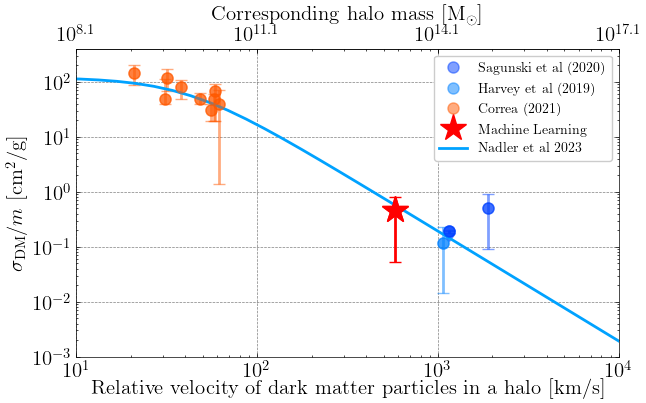

In [145]:
markersize = 12

fig = plt.figure(figsize=(7,4))
ax = plt.gca()


x = np.logspace(0,5)



ax.set_ylabel('$\sigma_{\\rm DM}/m$ [cm$^2$/g]', fontsize=15, wrap=True)
ax.set_xlabel('Relative velocity of dark matter particles in a halo [km/s]', fontsize=15, labelpad=-2)

ax.loglog()
ax.set_ylim(0.001,4e2)
ax.set_xlim(10,1e4)
def v_to_m(v):
    m = mass_from_velocity(v * units.km / units.s, redshift=0.3)
    return m

def m_to_v(m):
    # inverse of mass_from_velocity (using dummy v³ relation)
    v = v_from_m(m)
    return v

# Create top axis linked via transformation
top = ax.secondary_xaxis('top', functions=(v_to_m, m_to_v))
top.set_xscale('log')
top.set_xlabel('Corresponding halo mass [$\\rm M_\odot$]', fontsize=15)
#plt.text(0.5, 1.5, 'Corresponding halo mass [$\\rm M_\odot$]', fontsize=15, 
#         transform=top.transAxes, ha='center', va='bottom')


bottom_ticks = ax.get_xticks()                   # e.g., [1, 10, 100, ...]
top_ticks = v_to_m(bottom_ticks)                 # positions on top axis that correspond
top.set_xticks(top_ticks)

# Optional: set nice tick labels (e.g., log10 of mass) — choose whatever formatting you want:
top.set_xticklabels([f"{t:.1e}" for t in top_ticks])
def sci_notation(x, pos):
    if x == 0:
        return "0"
    exp = np.log10(x)
    #pre = 10**(np.log10(x) - exp)
    
    return rf"$10^{{{exp:.01f}}}$"  # e.g., 10^10, 10^11

top.xaxis.set_major_formatter(FuncFormatter(sci_notation))
#top.set_xlabel("Halo Mass $[M_\odot]$", fontsize=12)
ax.tick_params(axis='both', labelsize=15)
top.tick_params(axis='both',  labelsize=15)
plt.savefig("/Users/davidharvey/Desktop/nothing.pdf")

plot_constraints( ax=ax, select_these=['Dwarf_correa21','cluster_harvey19','sagunski'],
                labels={'Dwarf_correa21':'Correa (2021)','cluster_harvey19':'Harvey et al (2019)', 'sagunski':'Sagunski et al (2020)'})

lower_constraints =  {'range':[1e9,1e10],'error':40.,'label':'WP1', 'plotargs':{'ls':':','color':'k', 'lw':3}}
intermediate_constraints = {'range':[3e12,8e12],'error':1.,'label':'WP1', 'plotargs':{'ls':'-','color':'k', 'lw':3}}
upper_constraints = {'range':[3e14,3e15],'error':0.05,'label':'WP2', 'plotargs':{'ls':'-','color':'k', 'lw':3}}

#plot_constraints( intermediate_constraints,upper_constraints, lower_constraints)

velocity_disp = [522, 633]
#velocity_disp = [1750, 1750]

ax.plot( np.mean(velocity_disp), max_like, '*',
            markersize=20, color='red', lw=2, label='Machine Learning')
ax.errorbar( np.mean(velocity_disp), max_like, yerr=error[:,None], 
            markersize=20, color='red', fmt='*', capsize=4, lw=2)
ax.plot( x, sigma_vd( x, 120,40),  lw=2, color=(0,162/255.,255/255.), label='Nadler et al 2023')

ax.legend()
plt.savefig("/Users/davidharvey/Desktop/with_constraint.pdf")